# Deep Generative Prior — StyleGAN-XL Motion Deblurring and Denoising

Questo notebook usa un generatore StyleGAN-XL pre-addestrato su ImageNet come **Deep Generative Prior**.

La ricostruzione non viene ottimizzata direttamente nello spazio immagine.  
Per ogni immagine degradata si ottimizza il latente `w` del generatore, cercando un'immagine generata che, dopo applicazione della degradazione `K`, sia coerente con l'osservazione degradata.

La degradazione usata è la stessa degli altri metodi:

- motion blur con kernel `9x9`;
- angolo del blur pari a `45°`;
- rumore gaussiano con livelli `[0.005, 0.01, 0.05, 0.1]`.

Per ogni immagine e per ogni livello di rumore vengono testati diversi valori di `λ`.  
La migliore ricostruzione viene scelta in base al PSNR rispetto all'immagine pulita.


In [ ]:
# 1 - Setup and dataset

import os
from datasets import load_dataset
import torch
from torch.utils.data import Subset

from IPPy.utilities.metrics import PSNR, SSIM, RE

from utilities.image_dataset import ImageDataset
from utilities.degradation import (
    ImageDegradation,
    DegradationParameters,
    RGBBlurOperator,
)
from utilities.plotter import plot
from utilities.config import TEST_SIZE, TO_RECONSTRUCT_INDEXES

from models.heuristic_dgp import DGPImageReconstruction


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 256

NOISE_LEVELS = [
    0.005,
    0.01,
    0.05,
    0.1,
]

RESULTS_DIR = "results/DGP"

LAMBDA_VALUES = [
    0.0, 
    1e-7, 
    3e-7, 
    1e-6, 
    3e-6
]


ds = load_dataset(
    "benjamin-paine/imagenet-1k-256x256",
)

test_dataset = Subset(
    ImageDataset(ds["test"]),
    range(TEST_SIZE),
)


dgp = DGPImageReconstruction(
    model_name="biggan-deep-256",
    lambda_values=LAMBDA_VALUES,
    max_iters=300,
    learning_rate=1e-3,
    truncation=1.0,
    device=DEVICE,
)


print("Device:", DEVICE)
print("BigGAN loaded.")

print("z_dim:", dgp.z_dim)
print("c_dim:", dgp.c_dim)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/36 [00:00<?, ?it/s]

Device: cuda
BigGAN loaded.
z_dim: 128
c_dim: 1000


## Reconstruction

Per ogni immagine selezionata vengono generate quattro versioni degradate, una per ciascun livello di rumore.

Per ogni degradazione, il metodo DGP ricostruisce l'immagine usando tutti i valori di `λ` definiti in `LAMBDA_VALUES`.  
La migliore ricostruzione viene selezionata in base al PSNR.

Il PNG salvato contiene:

1. immagine pulita;
2. immagine degradata;
3. migliore ricostruzione DGP.


Estimated ImageNet class: 18 | magpie | p=0.3764
Sampling 1024 latent vectors and keeping top 4...
Best sampled latent scores:
  1: 0.040509
  2: 0.043915
  3: 0.044292
  4: 0.044852
Running latent optimisation with lambda = 1.0e-05
Optimising sampled latent 1 | initial score=0.040509
restart=1 | iter=0025 | loss=0.018908 | data=0.018903 | latent=0.469833
restart=1 | iter=0050 | loss=0.018503 | data=0.018499 | latent=0.478933
restart=1 | iter=0075 | loss=0.018310 | data=0.018305 | latent=0.487014
restart=1 | iter=0100 | loss=0.018180 | data=0.018175 | latent=0.492708
restart=1 | iter=0125 | loss=0.018086 | data=0.018081 | latent=0.496151
restart=1 | iter=0150 | loss=0.018008 | data=0.018003 | latent=0.500526
restart=1 | iter=0175 | loss=0.017944 | data=0.017939 | latent=0.504802
restart=1 | iter=0200 | loss=0.017875 | data=0.017870 | latent=0.508513
restart=1 | iter=0225 | loss=0.017823 | data=0.017818 | latent=0.513044
restart=1 | iter=0250 | loss=0.017768 | data=0.017763 | latent=0.5

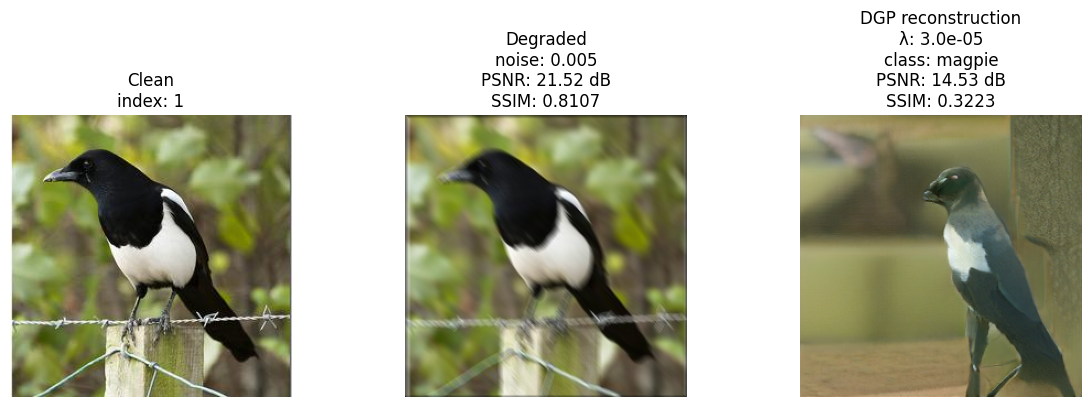

Estimated ImageNet class: 18 | magpie | p=0.4152
Sampling 1024 latent vectors and keeping top 4...
Best sampled latent scores:
  1: 0.043072
  2: 0.043109
  3: 0.043840
  4: 0.044505
Running latent optimisation with lambda = 1.0e-05
Optimising sampled latent 1 | initial score=0.043072
restart=1 | iter=0025 | loss=0.019535 | data=0.019531 | latent=0.467214
restart=1 | iter=0050 | loss=0.017373 | data=0.017368 | latent=0.470287
restart=1 | iter=0075 | loss=0.016605 | data=0.016600 | latent=0.473523
restart=1 | iter=0100 | loss=0.016256 | data=0.016251 | latent=0.477090
restart=1 | iter=0125 | loss=0.015993 | data=0.015988 | latent=0.482198
restart=1 | iter=0150 | loss=0.015793 | data=0.015788 | latent=0.488060
restart=1 | iter=0175 | loss=0.015613 | data=0.015608 | latent=0.494907
restart=1 | iter=0200 | loss=0.015410 | data=0.015405 | latent=0.503273
restart=1 | iter=0225 | loss=0.015220 | data=0.015215 | latent=0.511165
restart=1 | iter=0250 | loss=0.015101 | data=0.015096 | latent=0.5

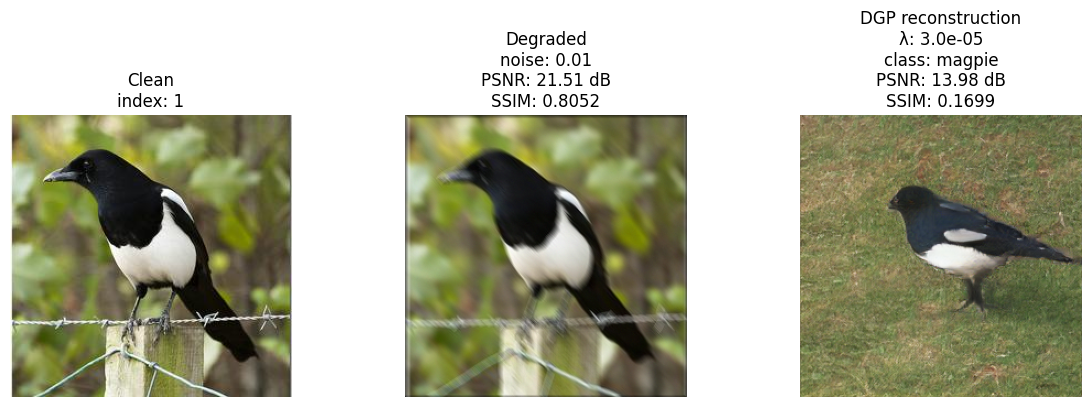

Estimated ImageNet class: 18 | magpie | p=0.5835
Sampling 1024 latent vectors and keeping top 4...
Best sampled latent scores:
  1: 0.044496
  2: 0.045556
  3: 0.045857
  4: 0.046744
Running latent optimisation with lambda = 1.0e-05
Optimising sampled latent 1 | initial score=0.044496
restart=1 | iter=0025 | loss=0.019846 | data=0.019840 | latent=0.542651
restart=1 | iter=0050 | loss=0.018138 | data=0.018133 | latent=0.547427
restart=1 | iter=0075 | loss=0.017596 | data=0.017590 | latent=0.554679
restart=1 | iter=0100 | loss=0.017208 | data=0.017203 | latent=0.563203
restart=1 | iter=0125 | loss=0.016807 | data=0.016801 | latent=0.575958
restart=1 | iter=0150 | loss=0.016504 | data=0.016499 | latent=0.585735
restart=1 | iter=0175 | loss=0.016292 | data=0.016286 | latent=0.592863
restart=1 | iter=0200 | loss=0.016111 | data=0.016105 | latent=0.599189
restart=1 | iter=0225 | loss=0.015936 | data=0.015930 | latent=0.605749
restart=1 | iter=0250 | loss=0.015743 | data=0.015737 | latent=0.6

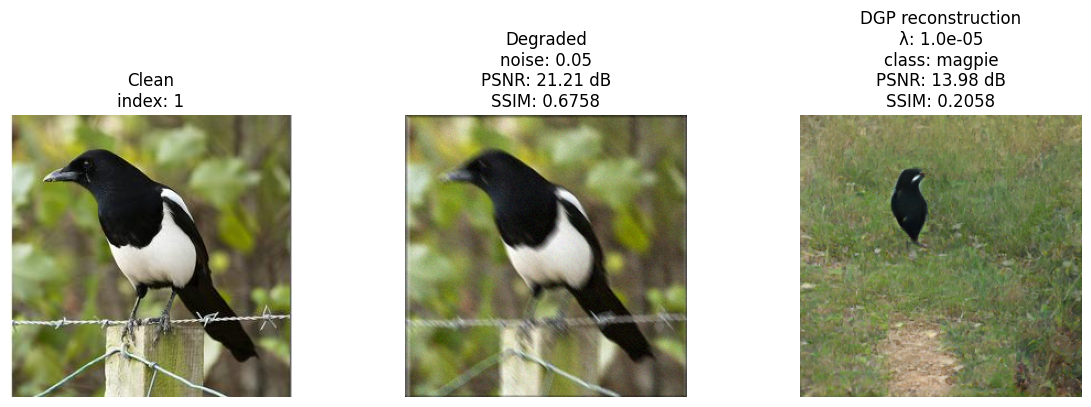

Estimated ImageNet class: 18 | magpie | p=0.5889
Sampling 1024 latent vectors and keeping top 4...
Best sampled latent scores:
  1: 0.044758
  2: 0.045229
  3: 0.045690
  4: 0.046385
Running latent optimisation with lambda = 1.0e-05
Optimising sampled latent 1 | initial score=0.044758
restart=1 | iter=0025 | loss=0.020404 | data=0.020398 | latent=0.586473
restart=1 | iter=0050 | loss=0.019892 | data=0.019886 | latent=0.592940
restart=1 | iter=0075 | loss=0.019562 | data=0.019556 | latent=0.594276
restart=1 | iter=0100 | loss=0.019286 | data=0.019280 | latent=0.591493
restart=1 | iter=0125 | loss=0.019071 | data=0.019065 | latent=0.591354
restart=1 | iter=0150 | loss=0.018863 | data=0.018857 | latent=0.592055
restart=1 | iter=0175 | loss=0.018611 | data=0.018605 | latent=0.593472
restart=1 | iter=0200 | loss=0.018306 | data=0.018300 | latent=0.598194
restart=1 | iter=0225 | loss=0.017838 | data=0.017831 | latent=0.608392
restart=1 | iter=0250 | loss=0.017334 | data=0.017328 | latent=0.6

KeyboardInterrupt: 

In [2]:
# 2 - DGP reconstruction on selected test images

all_dgp_results = []

for image_index in TO_RECONSTRUCT_INDEXES:
    clean = test_dataset[image_index].unsqueeze(0).to(DEVICE)

    for noise_level in NOISE_LEVELS:
        noise_name = f"noise_{int(noise_level * 1000):03d}"

        degradation = ImageDegradation(
            DegradationParameters(
                image_size=IMAGE_SIZE,
                kernel_type="motion",
                kernel_size=9,
                motion_angle=45,
                noise_levels=[noise_level],
            )
        )

        K_rgb = RGBBlurOperator(degradation.operator)

        with torch.no_grad():
            degraded = degradation(clean)

        save_dir = os.path.join(
            RESULTS_DIR,
            noise_name,
            f"image_{image_index}",
            "lambdas",
        )

        results = dgp(
            y_d=degraded,
            K=K_rgb,
            x_gt=clean,
            save_dir=save_dir,
            preview=False,
        )

        best_result = max(
            results,
            key=lambda result: result["psnr"],
        )

        best_reconstruction = best_result["reconstruction"]

        psnr_degraded = PSNR(degraded, clean)
        ssim_degraded = SSIM(degraded, clean)

        summary = {
            "image_index": image_index,
            "noise_level": noise_level,
            "best_lambda": best_result["lambda"],
            "class_index": best_result.get("class_index"),
            "class_name": best_result.get("class_name"),
            "class_probability": best_result.get("class_probability"),
            "psnr_degraded": psnr_degraded,
            "ssim_degraded": ssim_degraded,
            "psnr_dgp": best_result["psnr"],
            "ssim_dgp": best_result["ssim"],
            "re_dgp": best_result["re"],
        }

        all_dgp_results.append(summary)

        plot(
            clean,
            degraded,
            best_reconstruction,
            titles=[
                f"Clean\nindex: {image_index}",
                (
                    f"Degraded\n"
                    f"noise: {noise_level}\n"
                    f"PSNR: {psnr_degraded:.2f} dB\n"
                    f"SSIM: {ssim_degraded:.4f}"
                ),
                (
                    f"DGP reconstruction\n"
                    f"λ: {best_result['lambda']:.1e}\n"
                    f"class: {best_result.get('class_name', 'unknown')}\n"
                    f"PSNR: {best_result['psnr']:.2f} dB\n"
                    f"SSIM: {best_result['ssim']:.4f}"
                ),
            ],
            size=4,
            save_path=os.path.join(
                RESULTS_DIR,
                noise_name,
                f"image_{image_index}.png",
            ),
        )

torch.save(
    all_dgp_results,
    os.path.join(
        RESULTS_DIR,
        "dgp_summary.pt",
    ),
)

## Results summary

La cella seguente stampa una tabella compatta con il miglior valore di `λ` trovato per ogni immagine e per ogni livello di rumore.


In [ ]:
# 3 - Results summary

for result in all_dgp_results:
    print(
        f"image={result['image_index']} | "
        f"noise={result['noise_level']} | "
        f"best λ={result['best_lambda']:.1e} | "
        f"degraded PSNR={result['psnr_degraded']:.2f} dB | "
        f"DGP PSNR={result['psnr_dgp']:.2f} dB | "
        f"DGP SSIM={result['ssim_dgp']:.4f} | "
        f"DGP RE={result['re_dgp']:.4f}"
    )
